In [26]:
import numpy as np
import pandas as pd

data = {"study_hours":[1,2,3,4,5,6,7,8,9,10],
        "Att":[10,20,30,40,50,60,70,80,90,100],
        "Pass":[0,0,0,0,1,1,1,1,1,1]}
df = pd.DataFrame(data)
print(df)

   study_hours  Att  Pass
0            1   10     0
1            2   20     0
2            3   30     0
3            4   40     0
4            5   50     1
5            6   60     1
6            7   70     1
7            8   80     1
8            9   90     1
9           10  100     1


In [25]:
new_stu =np.array([5,1])
df["Distance"] = np.sqrt((df['study_hours']-new_stu[0])**2+(df["Att"]-new_stu[1])**2)
print(df)

#k nearest
k = 10
nearest_Stu = df.sort_values("Distance").head(k)
print("\nNearest students",nearest_Stu)
votes = nearest_Stu["Pass"]
print(votes.tolist())



   study_hours  Att  Pass   Distance
0            1   10     0   9.848858
1            2   20     0  19.235384
2            3   30     0  29.068884
3            4   40     0  39.012818
4            5   50     1  49.000000
5            6   60     1  59.008474
6            7   70     1  69.028979
7            8   80     1  79.056942
8            9   90     1  89.089842
9           10  100     1  99.126182

Nearest students    study_hours  Att  Pass   Distance
0            1   10     0   9.848858
1            2   20     0  19.235384
2            3   30     0  29.068884
3            4   40     0  39.012818
4            5   50     1  49.000000
5            6   60     1  59.008474
6            7   70     1  69.028979
7            8   80     1  79.056942
8            9   90     1  89.089842
9           10  100     1  99.126182
[0, 0, 0, 0, 1, 1, 1, 1, 1, 1]


## Visualization of K-Nearest Neighbors

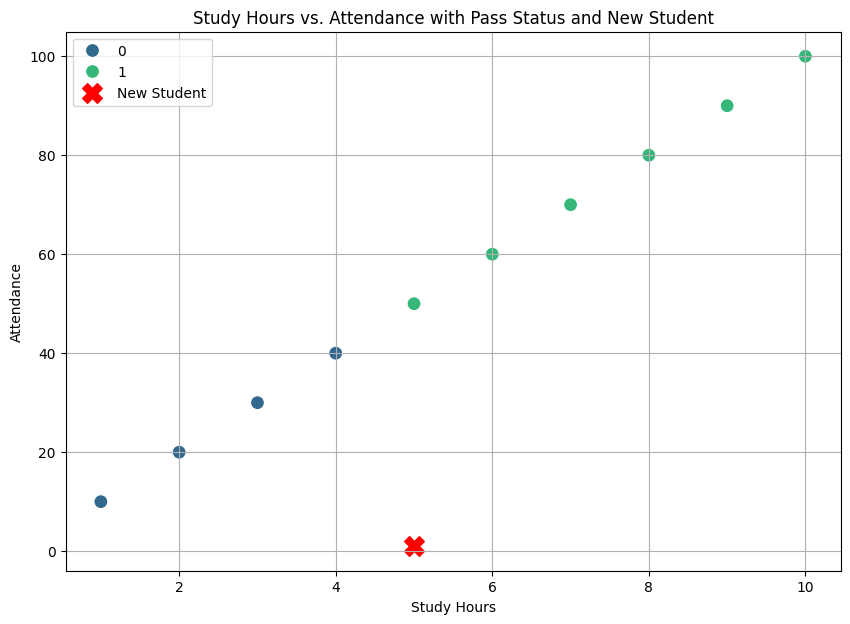

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='study_hours', y='Att', hue='Pass', data=df, s=100, palette='viridis', legend='full'
)

# Highlight the new student
plt.scatter(new_stu[0], new_stu[1], color='red', marker='X', s=200, label='New Student')

plt.title('Study Hours vs. Attendance with Pass Status and New Student')
plt.xlabel('Study Hours')
plt.ylabel('Attendance')
plt.grid(True)
plt.legend()
plt.show()

## What is K-Nearest Neighbors (KNN)?

K-Nearest Neighbors (KNN) is a simple, non-parametric, supervised machine learning algorithm that can be used for both classification and regression tasks. It's often used for classification. The algorithm works as follows:

1.  **Choose a value for K**: This is the number of nearest data points (neighbors) to consider.
2.  **Calculate Distance**: For a new data point, calculate its distance to all other data points in the training set.
3.  **Find K Nearest Neighbors**: Select the K data points that are closest to the new data point.
4.  **Vote for Classification**: For classification, the new data point is assigned the class label that is most common among its K nearest neighbors.
5.  **Average for Regression**: For regression, the value for the new data point is the average of the values of its K nearest neighbors.

## Euclidean Distance

Euclidean distance is the straight-line distance between two points in Euclidean space. It is a common distance metric used in the KNN algorithm.

For two points $P = (p_1, p_2, ..., p_n)$ and $Q = (q_1, q_2, ..., q_n)$ in n-dimensional space, the Euclidean distance is calculated using the formula:

$$ d(P, Q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + ... + (p_n - q_n)^2} $$

In our 2-dimensional example, for a new student with `study_hours` ($x_1$) and `Att` ($y_1$) and an existing student with `study_hours` ($x_2$) and `Att` ($y_2$), the distance is:

$$ d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2} $$

## Sample Calculation: K-Nearest Neighbors

Let's take our `new_stu` which has `study_hours` = 5 and `Att` = 1. We'll pick two of the closest students from our `nearest_Stu` DataFrame to demonstrate the Euclidean distance calculation and how the 'Pass' vote works.

In [28]:
# New student's features
x1, y1 = new_stu[0], new_stu[1]
print(f"New Student: (Study Hours={x1}, Attendance={y1})\n")

# Let's consider the first two nearest students from our previously calculated 'nearest_Stu' DataFrame
student1 = nearest_Stu.iloc[0]
student2 = nearest_Stu.iloc[1]

# Student 1 features and Pass status
x2_s1, y2_s1 = student1['study_hours'], student1['Att']
pass_s1 = student1['Pass']

# Student 2 features and Pass status
x2_s2, y2_s2 = student2['study_hours'], student2['Att']
pass_s2 = student2['Pass']

print(f"Student 1: (Study Hours={x2_s1}, Attendance={y2_s1}), Pass={pass_s1}")
print(f"Student 2: (Study Hours={x2_s2}, Attendance={y2_s2}), Pass={pass_s2}\n")

# Calculate Euclidean distance for Student 1
distance_s1 = np.sqrt((x1 - x2_s1)**2 + (y1 - y2_s1)**2)
print(f"Euclidean Distance to Student 1: {distance_s1:.2f}")

# Calculate Euclidean distance for Student 2
distance_s2 = np.sqrt((x1 - x2_s2)**2 + (y1 - y2_s2)**2)
print(f"Euclidean Distance to Student 2: {distance_s2:.2f}\n")

print("These distances match the 'Distance' column in the `nearest_Stu` DataFrame.")

# Now, let's determine the predicted 'Pass' status based on these two neighbors (assuming k=2)
# For k=2, we have one neighbor with Pass=0 and one with Pass=0.
# The majority vote is 0.

# If we consider the original k=10 from the problem description:
# The votes are: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
# Counting the votes:
pass_votes = votes.sum() # Count of 1s
fail_votes = len(votes) - pass_votes # Count of 0s

print(f"\nConsidering k={k} nearest neighbors:")
print(f"Number of 'Pass' votes (1s): {pass_votes}")
print(f"Number of 'Fail' votes (0s): {fail_votes}")

if pass_votes > fail_votes:
    prediction = 1
    print(f"Based on {k} neighbors, the new student is predicted to Pass (Class: {prediction})")
elif fail_votes > pass_votes:
    prediction = 0
    print(f"Based on {k} neighbors, the new student is predicted to Fail (Class: {prediction})")
else:
    print(f"Based on {k} neighbors, it's a tie, additional rules would be needed (e.g., reduce k, weighted vote).")

New Student: (Study Hours=5, Attendance=1)

Student 1: (Study Hours=1.0, Attendance=10.0), Pass=0.0
Student 2: (Study Hours=2.0, Attendance=20.0), Pass=0.0

Euclidean Distance to Student 1: 9.85
Euclidean Distance to Student 2: 19.24

These distances match the 'Distance' column in the `nearest_Stu` DataFrame.

Considering k=10 nearest neighbors:
Number of 'Pass' votes (1s): 6
Number of 'Fail' votes (0s): 4
Based on 10 neighbors, the new student is predicted to Pass (Class: 1)
